**Instructions:**
- প্রতিটি cell এ `# YOUR CODE HERE` এর জায়গায় তোমার code লেখো।
- Expected output এর সাথে নিজের output মেলাও।
- `Shift + Enter` দিয়ে cell run করো।

---

## Name: Md. Ammar Hamim
## gmail: ammarhamim7@gmail.com

## ⚙️ Setup — Run This First

In [569]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer

np.random.seed(42)
data = {
    'Age':        [25, 32, np.nan, 45, 28, 60, 22, 38, np.nan, 55, 29, 200, 34, 41, 26],
    'Salary':     [30000, 55000, 48000, np.nan, 32000, 75000, 28000, 60000, 41000, 70000, 33000, 52000, np.nan, 63000, 29000],
    'City':       ['Dhaka','Chittagong','Dhaka','Sylhet',np.nan,'Dhaka','Rajshahi','Chittagong','Dhaka','Sylhet','Rajshahi','Dhaka','Chittagong',np.nan,'Dhaka'],
    'Education':  ['HSC','Graduate','Graduate','Masters','HSC','PhD','HSC','Graduate','Masters','PhD','HSC','Graduate','Graduate','Masters','HSC'],
    'Experience': [2, 8, 5, 15, 3, 30, 1, 12, 7, 25, 2, 9, 6, 18, 3],
    'Purchased':  [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0]
}
df = pd.DataFrame(data)
print('Dataset loaded! Shape:', df.shape)
df.head()

Dataset loaded! Shape: (15, 6)


,Age,Salary,City,Education,Experience,Purchased
0,25.0,30000.0,Dhaka,HSC,2,0
1,32.0,55000.0,Chittagong,Graduate,8,1
2,NaN,48000.0,Dhaka,Graduate,5,1
3,45.0,NaN,Sylhet,Masters,15,1
4,28.0,32000.0,NaN,HSC,3,0


---
# 📌 Section 1: Exploratory Data Analysis
**Module 01 & 02**

### 🟢 EASY &nbsp;&nbsp; Question 1
Dataset এর **shape** বের করো — কতটি row এবং column আছে?

In [570]:
df.shape


(15, 6)

**Expected Output:** `(15, 6)`

### 🟢 EASY &nbsp;&nbsp; Question 2
প্রতিটি column এর **data type** দেখাও।

In [571]:
df.dtypes


,0
Age,float64
Salary,float64
City,object
Education,object
Experience,int64
Purchased,int64


### 🟢 EASY &nbsp;&nbsp; Question 3
Dataset এর **statistical summary** দেখাও — mean, std, min, max।

In [572]:
df.describe()


,Age,Salary,Experience,Purchased
count,13.000000,13.000000,15.000000,15.000000
mean,48.846154,47384.615385,9.733333,0.600000
std,46.857668,16474.922668,8.778762,0.507093
min,22.000000,28000.000000,1.000000,0.000000
25%,28.000000,32000.000000,3.000000,0.000000
50%,34.000000,48000.000000,7.000000,1.000000
75%,45.000000,60000.000000,13.500000,1.000000
max,200.000000,75000.000000,30.000000,1.000000


### 🟢 EASY &nbsp;&nbsp; Question 4
**City** column এ কতটি unique value আছে এবং প্রতিটি কতবার আসে?

In [573]:
df.nunique()


,0
Age,13
Salary,13
City,4
Education,4
Experience,13
Purchased,2


In [574]:
df.value_counts()

,,,,,,count
Age,Salary,City,Education,Experience,Purchased,
22.0,28000.0,Rajshahi,HSC,1,0,1
25.0,30000.0,Dhaka,HSC,2,0,1
26.0,29000.0,Dhaka,HSC,3,0,1
29.0,33000.0,Rajshahi,HSC,2,0,1
32.0,55000.0,Chittagong,Graduate,8,1,1
38.0,60000.0,Chittagong,Graduate,12,1,1
55.0,70000.0,Sylhet,PhD,25,1,1
60.0,75000.0,Dhaka,PhD,30,1,1
200.0,52000.0,Dhaka,Graduate,9,1,1


### 🟡 MEDIUM &nbsp;&nbsp; Question 5
**Age** column এর mean, median এবং mode আলাদাভাবে বের করো এবং তিনটি একসাথে print করো।

In [575]:
print(df['Age'].mean())
print(df['Age'].median())
print(df['Age'].mode())


48.84615384615385
34.0
0      22.0
1      25.0
2      26.0
3      28.0
4      29.0
5      32.0
6      34.0
7      38.0
8      41.0
9      45.0
10     55.0
11     60.0
12    200.0
Name: Age, dtype: float64


### 🟡 MEDIUM &nbsp;&nbsp; Question 6
**Age** এর distribution দেখানোর জন্য histogram plot করো। Title এবং axis labels দাও।

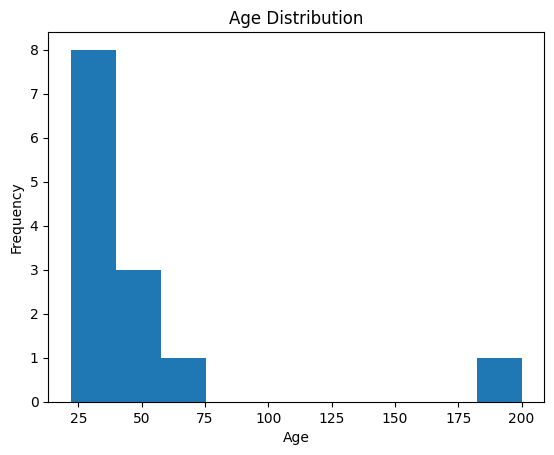

In [576]:
# YOUR CODE HERE
# Hint: plt.hist() বা df['Age'].plot(kind='hist')
# plt.title(), plt.xlabel(), plt.ylabel() দিতে ভুলো না

plt.hist(x=df['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


### 🟡 MEDIUM &nbsp;&nbsp; Question 7
**Salary vs Experience** scatter plot করো এবং দেখো কোনো pattern আছে কিনা।

<Axes: xlabel='Experience', ylabel='Salary'>

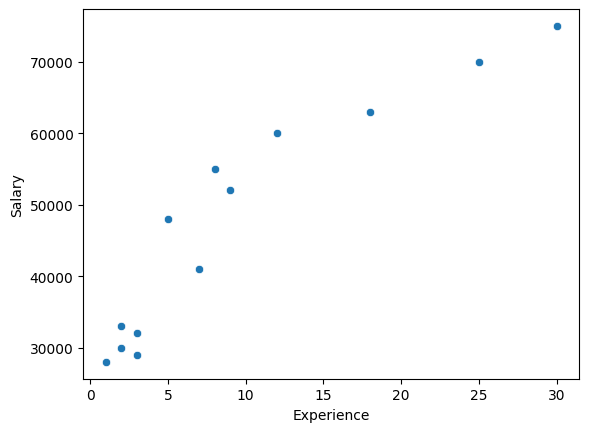

In [577]:
sns.scatterplot(data=df, x='Experience', y='Salary')

# higher the exp higher the sal

### 🔴 HARD &nbsp;&nbsp; Question 8
Numerical columns এর correlation বের করো এবং **heatmap** দিয়ে visualize করো। `annot=True` দাও।

> চিন্তা করো: Age এবং Experience এর মধ্যে কি strong correlation আছে? কেন?

In [578]:
corr_mat=df.corr(numeric_only=True)
corr_mat


,Age,Salary,Experience,Purchased
Age,1.000000,0.295888,0.200245,0.401193
Salary,0.295888,1.000000,0.926564,0.890103
Experience,0.200245,0.926564,1.000000,0.648235
Purchased,0.401193,0.890103,0.648235,1.000000


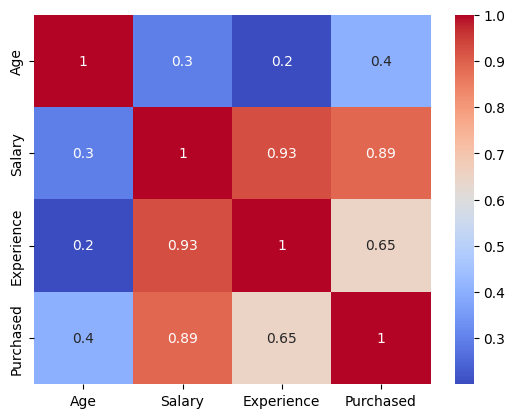

In [579]:
sns.heatmap(corr_mat,annot=True, cmap='coolwarm')
plt.show()

---
# 📌 Section 2: Train-Test Split & Missing Value Handling
**Module 03**

### 🟢 EASY &nbsp;&nbsp; Question 9
প্রতিটি column এ **কতটি missing value** আছে তা বের করো।

In [580]:
df.isnull().sum()


,0
Age,2
Salary,2
City,2
Education,0
Experience,0
Purchased,0


**Expected:** Age=2, Salary=2, City=2

### 🟢 EASY &nbsp;&nbsp; Question 10
**Age** এর missing values **mean** দিয়ে এবং **City** এর missing values **mode** দিয়ে fill করো।

In [581]:
from sklearn.impute import SimpleImputer

df_clean = df.copy()

imputer=SimpleImputer(strategy='mean')
df_clean['Age']=imputer.fit_transform(df_clean[['Age']]).ravel()

imputer=SimpleImputer(strategy='most_frequent')
df_clean['City']=imputer.fit_transform(df_clean[['City']]).ravel()

df_clean.isnull().sum()


,0
Age,0
Salary,2
City,0
Education,0
Experience,0
Purchased,0


### 🟡 MEDIUM &nbsp;&nbsp; Question 11
**Salary** এর missing values **median** দিয়ে fill করো। Fill করার আগে ও পরে missing count দেখাও।

In [582]:
df_clean['Salary'].isnull().sum()


np.int64(2)

In [583]:
df_clean['Salary'].fillna(df['Salary'].median(),inplace=True)

/tmp/ipykernel_2602/4142683154.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Salary'].fillna(df['Salary'].median(),inplace=True)


In [584]:
df_clean['Salary'].isnull().sum()

np.int64(0)

### 🟡 MEDIUM &nbsp;&nbsp; Question 12
**Train-Test Split** করো — 80% training, 20% testing। `random_state=42`।

> Feature (X): Age, Salary, Experience | Target (y): Purchased

In [585]:
X = df_clean[['Age', 'Salary', 'Experience']]
y = df_clean['Purchased']

In [586]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [587]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((12, 3), (3, 3), (12,), (3,))

**Expected:** Train size: 12, Test size: 3

### 🔴 HARD &nbsp;&nbsp; Question 13
Train-Test Split করার পরে `y_train` এবং `y_test` এ **class distribution** (0 এবং 1 এর ratio) দেখাও। Distribution কি balanced?

> Hint: `.value_counts(normalize=True)` দিয়ে percentage বের করো।

In [588]:
# y_train distribution
y_train.value_counts(normalize=True)


,proportion
Purchased,
1,0.583333
0,0.416667


In [589]:
# y_test distribution
y_test.value_counts(normalize=True)

,proportion
Purchased,
1,0.666667
0,0.333333


In [590]:
# "Train এ class 0 আছে 58.33%, class 1 আছে 41.66%"
# "Test এ class 0 আছে 66.66%, class 1 আছে 33.33%"

# hence the dist is not balanced

---
# 📌 Section 3: Outlier Detection and Handling
**Module 05 & 06**

### 🟢 EASY &nbsp;&nbsp; Question 14
**Age** column এর **boxplot** তৈরি করো।

<Axes: ylabel='Age'>

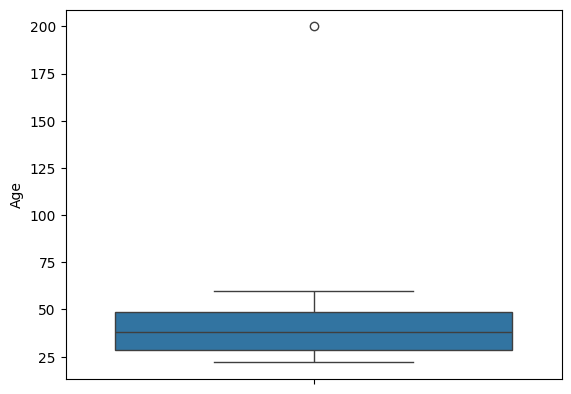

In [591]:
sns.boxplot(y=df_clean['Age'])


**Note:** Age=200 clearly একটি outlier।

### 🟡 MEDIUM &nbsp;&nbsp; Question 15
**IQR Method** দিয়ে **Age** column এর outlier detect করো এবং outlier rows দেখাও।

> IQR = Q3 - Q1 | Lower = Q1 - 1.5×IQR | Upper = Q3 + 1.5×IQR

In [592]:
Q1 = df_clean['Age'].quantile(0.25)
Q3 = df_clean['Age'].quantile(0.75)

IQR=Q3-Q1

lb=max(0,Q1-1.5*IQR)
ub=Q3+1.5*IQR

print(lb,ub)

0 79.36538461538461


In [593]:
outliers=df_clean[(df_clean['Age']<lb) | (df_clean['Age']>ub)]
print(outliers.shape)

outliers

(1, 6)


,Age,Salary,City,Education,Experience,Purchased
11,200.0,52000.0,Dhaka,Graduate,9,1


**Expected:** Age=200 row outlier হিসেবে detected হবে।

### 🟡 MEDIUM &nbsp;&nbsp; Question 16
**Z-Score Method** দিয়ে outlier detect করো। |Z| > 3 হলে outlier।

> Z = (x - mean) / std

In [594]:
# YOUR CODE HERE
mean_age = df_clean['Age'].mean()
std_age  = df_clean['Age'].std()

df_clean['ZscoreAge']=(df_clean['Age']-mean_age)/std_age

df_clean


,Age,Salary,City,Education,Experience,Purchased,ZscoreAge
0,25.000000,30000.0,Dhaka,HSC,2,0,-5.496814e-01
1,32.000000,55000.0,Chittagong,Graduate,8,1,-3.883233e-01
2,48.846154,48000.0,Dhaka,Graduate,5,1,1.637883e-16
3,45.000000,48000.0,Sylhet,Masters,15,1,-8.865830e-02
4,28.000000,32000.0,Dhaka,HSC,3,0,-4.805280e-01
5,60.000000,75000.0,Dhaka,PhD,30,1,2.571091e-01
6,22.000000,28000.0,Rajshahi,HSC,1,0,-6.188349e-01
7,38.000000,60000.0,Chittagong,Graduate,12,1,-2.500164e-01
8,48.846154,41000.0,Dhaka,Masters,7,0,1.637883e-16
9,55.000000,70000.0,Sylhet,PhD,25,1,1.418533e-01


In [595]:
df_clean[df_clean['ZscoreAge'].abs()>3]

,Age,Salary,City,Education,Experience,Purchased,ZscoreAge
11,200.0,52000.0,Dhaka,Graduate,9,1,3.484271


In [596]:
df_clean.drop('ZscoreAge',axis=1,inplace=True)

### 🟡 MEDIUM &nbsp;&nbsp; Question 17
IQR method এ detected outlier rows **remove** করো। নতুন shape দেখাও।

In [597]:
df_cpy=df_clean.copy()
df_clean.shape

(15, 6)

In [598]:
df_clean = df_clean[(df_clean['Age'] >= lb) & (df_clean['Age'] <= ub)]
df_clean.shape

(14, 6)

**Expected:** Shape (14, 6) — 1 row removed.

### 🔴 HARD &nbsp;&nbsp; Question 18
Outlier remove করার বদলে **cap** করো (Winsorization)। তারপর before vs after boxplot side-by-side দেখাও।

> Cap মানে: outlier value কে bound এর value দিয়ে replace করা।

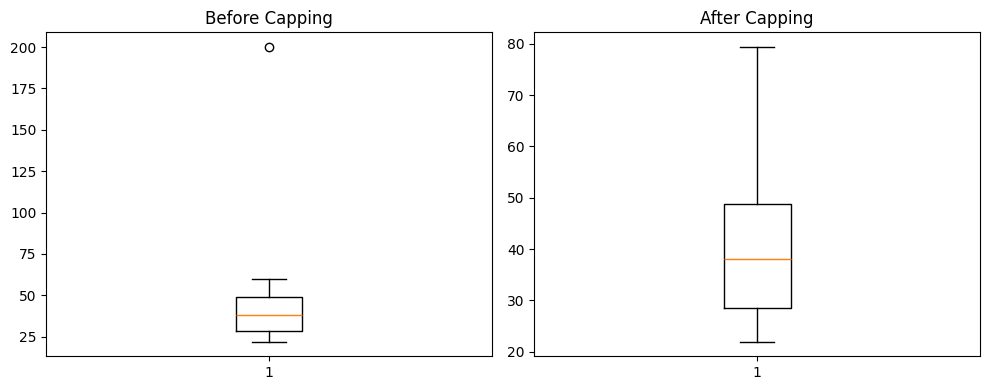

In [599]:
df_capped = df_cpy.copy()

df_capped['Age'] = df_capped['Age'].clip(lb,ub)

# Step 2: Before vs After boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


axes[0].boxplot(df_cpy['Age'])
axes[0].set_title("Before Capping")


axes[1].boxplot(df_capped['Age'])
axes[1].set_title("After Capping")


plt.tight_layout()
plt.show()

---
# 📌 Section 4: Encoding
**Module 07**

### 🟢 EASY &nbsp;&nbsp; Question 19
**Label Encoding** দিয়ে **Education** column কে numerical করো।

In [600]:
df_clean['Education'].value_counts()

,count
Education,
HSC,5
Graduate,4
Masters,3
PhD,2


In [601]:
df_encoded = df_clean.copy()
le = LabelEncoder()
df_encoded['Education_Encoded'] = le.fit_transform(df_encoded[['Education']]).ravel()


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [602]:
df_encoded

,Age,Salary,City,Education,Experience,Purchased,Education_Encoded
0,25.000000,30000.0,Dhaka,HSC,2,0,1
1,32.000000,55000.0,Chittagong,Graduate,8,1,0
2,48.846154,48000.0,Dhaka,Graduate,5,1,0
3,45.000000,48000.0,Sylhet,Masters,15,1,2
4,28.000000,32000.0,Dhaka,HSC,3,0,1
5,60.000000,75000.0,Dhaka,PhD,30,1,3
6,22.000000,28000.0,Rajshahi,HSC,1,0,1
7,38.000000,60000.0,Chittagong,Graduate,12,1,0
8,48.846154,41000.0,Dhaka,Masters,7,0,2
9,55.000000,70000.0,Sylhet,PhD,25,1,3


In [603]:
df_encoded['Education_Encoded'].value_counts()

,count
Education_Encoded,
1,5
0,4
2,3
3,2


### 🟢 EASY &nbsp;&nbsp; Question 20
**One-Hot Encoding** দিয়ে **City** column কে encode করো। `pd.get_dummies()` ব্যবহার করো।

In [604]:
df_encoded=pd.get_dummies(df_encoded, columns=['City'],drop_first=True)

df_encoded


,Age,Salary,Education,Experience,Purchased,Education_Encoded,City_Dhaka,City_Rajshahi,City_Sylhet
0,25.000000,30000.0,HSC,2,0,1,True,False,False
1,32.000000,55000.0,Graduate,8,1,0,False,False,False
2,48.846154,48000.0,Graduate,5,1,0,True,False,False
3,45.000000,48000.0,Masters,15,1,2,False,False,True
4,28.000000,32000.0,HSC,3,0,1,True,False,False
5,60.000000,75000.0,PhD,30,1,3,True,False,False
6,22.000000,28000.0,HSC,1,0,1,False,True,False
7,38.000000,60000.0,Graduate,12,1,0,False,False,False
8,48.846154,41000.0,Masters,7,0,2,True,False,False
9,55.000000,70000.0,PhD,25,1,3,False,False,True


**Note:** `drop_first=True` দিলে dummy variable trap avoid হয়।

### 🟡 MEDIUM &nbsp;&nbsp; Question 21
Label Encoded **Education** এর mapping dictionary দেখাও — কোন label কোন number পেয়েছে।

In [605]:
mapping=dict(zip(le.classes_, le.transform(le.classes_)))
print(type(mapping))

mapping

<class 'dict'>


{'Graduate': np.int64(0),
 'HSC': np.int64(1),
 'Masters': np.int64(2),
 'PhD': np.int64(3)}

**Expected:** `{'Graduate': 0, 'HSC': 1, 'Masters': 2, 'PhD': 3}`

### 🔴 HARD &nbsp;&nbsp; Question 22
Label Encoding এবং One-Hot Encoding এর মধ্যে পার্থক্য কী? **Education** column এ কোনটা ব্যবহার করা সঠিক এবং কেন?

> দুটো method ই apply করো এবং output compare করো। তারপর নিচে comment এ তোমার reasoning লেখো।

In [606]:
df_encoded['Education'].value_counts()

,count
Education,
HSC,5
Graduate,4
Masters,3
PhD,2


In [607]:
# Method 1: Label Encoding
le = LabelEncoder()

df_encoded['EduLE']=le.fit_transform(df_encoded['Education'])
df_encoded


,Age,Salary,Education,Experience,Purchased,Education_Encoded,City_Dhaka,City_Rajshahi,City_Sylhet,EduLE
0,25.000000,30000.0,HSC,2,0,1,True,False,False,1
1,32.000000,55000.0,Graduate,8,1,0,False,False,False,0
2,48.846154,48000.0,Graduate,5,1,0,True,False,False,0
3,45.000000,48000.0,Masters,15,1,2,False,False,True,2
4,28.000000,32000.0,HSC,3,0,1,True,False,False,1
5,60.000000,75000.0,PhD,30,1,3,True,False,False,3
6,22.000000,28000.0,HSC,1,0,1,False,True,False,1
7,38.000000,60000.0,Graduate,12,1,0,False,False,False,0
8,48.846154,41000.0,Masters,7,0,2,True,False,False,2
9,55.000000,70000.0,PhD,25,1,3,False,False,True,3


In [608]:
# Method 2: One-Hot Encoding

ohe=OneHotEncoder(sparse_output=False,drop='first').set_output(transform='pandas')
eduOhe=ohe.fit_transform(df_encoded[['Education']])

df_encoded=pd.concat([df_encoded,eduOhe],axis=1)
df_encoded

,Age,Salary,Education,Experience,Purchased,Education_Encoded,City_Dhaka,City_Rajshahi,City_Sylhet,EduLE,Education_HSC,Education_Masters,Education_PhD
0,25.000000,30000.0,HSC,2,0,1,True,False,False,1,1.0,0.0,0.0
1,32.000000,55000.0,Graduate,8,1,0,False,False,False,0,0.0,0.0,0.0
2,48.846154,48000.0,Graduate,5,1,0,True,False,False,0,0.0,0.0,0.0
3,45.000000,48000.0,Masters,15,1,2,False,False,True,2,0.0,1.0,0.0
4,28.000000,32000.0,HSC,3,0,1,True,False,False,1,1.0,0.0,0.0
5,60.000000,75000.0,PhD,30,1,3,True,False,False,3,0.0,0.0,1.0
6,22.000000,28000.0,HSC,1,0,1,False,True,False,1,1.0,0.0,0.0
7,38.000000,60000.0,Graduate,12,1,0,False,False,False,0,0.0,0.0,0.0
8,48.846154,41000.0,Masters,7,0,2,True,False,False,2,0.0,1.0,0.0
9,55.000000,70000.0,PhD,25,1,3,False,False,True,3,0.0,0.0,1.0


In [609]:
# Education column এ Ordinal/Label Encoding ভালো কারণ Education এর natural order আছে
# One-Hot Encoding করলে order information হারিয়ে যায়।
# but i guess ordinalEncoding will be most suited here

---
# 📌 Section 5: Scaling
**Module 08**

### 🟢 EASY &nbsp;&nbsp; Question 23
**MinMaxScaler** দিয়ে **Experience** column কে 0–1 এর মধ্যে scale করো।

> Formula: x_scaled = (x - min) / (max - min)

In [610]:
df_scaled  = df_clean.copy()

In [611]:
df_scaled

,Age,Salary,City,Education,Experience,Purchased
0,25.000000,30000.0,Dhaka,HSC,2,0
1,32.000000,55000.0,Chittagong,Graduate,8,1
2,48.846154,48000.0,Dhaka,Graduate,5,1
3,45.000000,48000.0,Sylhet,Masters,15,1
4,28.000000,32000.0,Dhaka,HSC,3,0
5,60.000000,75000.0,Dhaka,PhD,30,1
6,22.000000,28000.0,Rajshahi,HSC,1,0
7,38.000000,60000.0,Chittagong,Graduate,12,1
8,48.846154,41000.0,Dhaka,Masters,7,0
9,55.000000,70000.0,Sylhet,PhD,25,1


In [612]:
mm_scaler = MinMaxScaler()

df_scaled['Experience']=mm_scaler.fit_transform(df_scaled[['Experience']])

df_scaled


,Age,Salary,City,Education,Experience,Purchased
0,25.000000,30000.0,Dhaka,HSC,0.034483,0
1,32.000000,55000.0,Chittagong,Graduate,0.241379,1
2,48.846154,48000.0,Dhaka,Graduate,0.137931,1
3,45.000000,48000.0,Sylhet,Masters,0.482759,1
4,28.000000,32000.0,Dhaka,HSC,0.068966,0
5,60.000000,75000.0,Dhaka,PhD,1.000000,1
6,22.000000,28000.0,Rajshahi,HSC,0.000000,0
7,38.000000,60000.0,Chittagong,Graduate,0.379310,1
8,48.846154,41000.0,Dhaka,Masters,0.206897,0
9,55.000000,70000.0,Sylhet,PhD,0.827586,1


**Expected:** Experience values এখন 0.0 থেকে 1.0 এর মধ্যে।

### 🟡 MEDIUM &nbsp;&nbsp; Question 24
**StandardScaler** দিয়ে **Age** এবং **Salary** scale করো। Scaling এর পর mean ≈ 0 এবং std ≈ 1 verify করো।

In [613]:
df_scaled['Age'].mean(),df_scaled['Age'].std(),df_scaled['Salary'].mean(),df_scaled['Salary'].std()

(np.float64(38.04945054945055),
 11.987955081642133,
 np.float64(47142.857142857145),
 15776.599725577717)

In [614]:
std_scaler = StandardScaler()

df_scaled['Age']=std_scaler.fit_transform(df_scaled[['Age']])
df_scaled['Salary']=std_scaler.fit_transform(df_scaled[['Salary']])

df_scaled


,Age,Salary,City,Education,Experience,Purchased
0,-1.129638,-1.127618,Dhaka,HSC,0.034483,0
1,-0.523677,0.516825,Chittagong,Graduate,0.241379,1
2,0.934627,0.056381,Dhaka,Graduate,0.137931,1
3,0.601681,0.056381,Sylhet,Masters,0.482759,1
4,-0.869941,-0.996063,Dhaka,HSC,0.068966,0
5,1.900171,1.832380,Dhaka,PhD,1.000000,1
6,-1.389336,-1.259174,Rajshahi,HSC,0.000000,0
7,-0.004281,0.845714,Chittagong,Graduate,0.379310,1
8,0.934627,-0.404063,Dhaka,Masters,0.206897,0
9,1.467341,1.503491,Sylhet,PhD,0.827586,1


In [615]:
print(round(df_scaled['Age'].mean()))
print(round(df_scaled['Age'].std()))

print(round(df_scaled['Salary'].mean()))
print(round(df_scaled['Salary'].std()))

0
1
0
1


**Expected:** Mean ≈ 0.0, Std ≈ 1.0

### 🟡 MEDIUM &nbsp;&nbsp; Question 25
**Age** column এর scaling এর আগে ও পরে distribution **side-by-side histogram** দিয়ে compare করো।

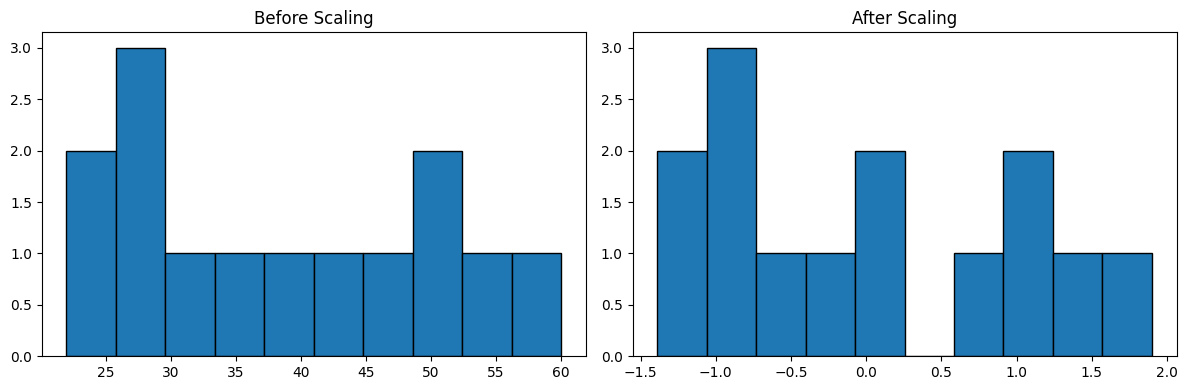

In [616]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(df_clean['Age'],edgecolor='black')
axes[0].set_title("Before Scaling")


axes[1].hist(df_scaled['Age'],edgecolor='black')
axes[1].set_title("After Scaling")

plt.tight_layout()
plt.show()

### 🔴 HARD &nbsp;&nbsp; Question 26
StandardScaler এবং MinMaxScaler এর মধ্যে পার্থক্য কী? **Salary** column এ দুটোই apply করো এবং output compare করো।

> কোন situation এ কোনটা use করবে? Comment এ reasoning লেখো।

In [617]:
salary = df_clean[['Salary']]

# StandardScaler apply করো

ss=StandardScaler()

df_scaled['salSTD']=ss.fit_transform(salary)

df_scaled


,Age,Salary,City,Education,Experience,Purchased,salSTD
0,-1.129638,-1.127618,Dhaka,HSC,0.034483,0,-1.127618
1,-0.523677,0.516825,Chittagong,Graduate,0.241379,1,0.516825
2,0.934627,0.056381,Dhaka,Graduate,0.137931,1,0.056381
3,0.601681,0.056381,Sylhet,Masters,0.482759,1,0.056381
4,-0.869941,-0.996063,Dhaka,HSC,0.068966,0,-0.996063
5,1.900171,1.832380,Dhaka,PhD,1.000000,1,1.832380
6,-1.389336,-1.259174,Rajshahi,HSC,0.000000,0,-1.259174
7,-0.004281,0.845714,Chittagong,Graduate,0.379310,1,0.845714
8,0.934627,-0.404063,Dhaka,Masters,0.206897,0,-0.404063
9,1.467341,1.503491,Sylhet,PhD,0.827586,1,1.503491


In [618]:
# MinMaxScaler apply করো
mm=MinMaxScaler()

df_scaled['salMMS']=mm.fit_transform(salary)
df_scaled

,Age,Salary,City,Education,Experience,Purchased,salSTD,salMMS
0,-1.129638,-1.127618,Dhaka,HSC,0.034483,0,-1.127618,0.042553
1,-0.523677,0.516825,Chittagong,Graduate,0.241379,1,0.516825,0.574468
2,0.934627,0.056381,Dhaka,Graduate,0.137931,1,0.056381,0.425532
3,0.601681,0.056381,Sylhet,Masters,0.482759,1,0.056381,0.425532
4,-0.869941,-0.996063,Dhaka,HSC,0.068966,0,-0.996063,0.085106
5,1.900171,1.832380,Dhaka,PhD,1.000000,1,1.832380,1.000000
6,-1.389336,-1.259174,Rajshahi,HSC,0.000000,0,-1.259174,0.000000
7,-0.004281,0.845714,Chittagong,Graduate,0.379310,1,0.845714,0.680851
8,0.934627,-0.404063,Dhaka,Masters,0.206897,0,-0.404063,0.276596
9,1.467341,1.503491,Sylhet,PhD,0.827586,1,1.503491,0.893617


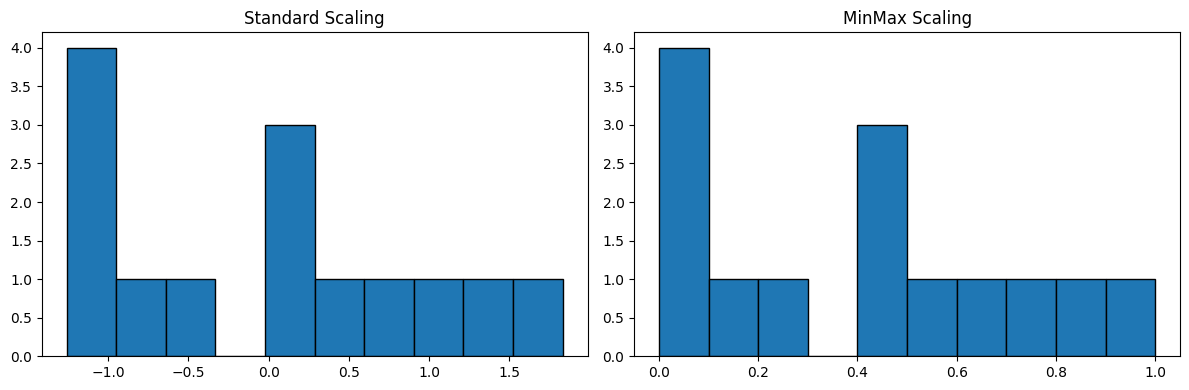

In [619]:
fig,axes=plt.subplots(1,2,figsize=(12,4))

axes[0].hist(df_scaled['salSTD'],edgecolor='black')
axes[0].set_title("Standard Scaling")


axes[1].hist(df_scaled['salMMS'],edgecolor='black')
axes[1].set_title("MinMax Scaling")

plt.tight_layout()
plt.show()

---
# 🌟 Bonus: Full Pipeline
**Combine everything — end-to-end preprocessing**

### 🔴 HARD &nbsp;&nbsp; Question 27 (Bonus)
নিচের সব steps follow করে একটি **complete preprocessing pipeline** তৈরি করো:

1. Missing values handle করো
2. Outliers cap করো (IQR method)
3. City → One-Hot Encode
4. Education → Label Encode
5. Age, Salary, Experience → StandardScale
6. 80/20 Train-Test Split
7. Final train/test shape print করো

In [620]:
df_pipeline = df.copy()

df_pipeline


,Age,Salary,City,Education,Experience,Purchased
0,25.0,30000.0,Dhaka,HSC,2,0
1,32.0,55000.0,Chittagong,Graduate,8,1
2,NaN,48000.0,Dhaka,Graduate,5,1
3,45.0,NaN,Sylhet,Masters,15,1
4,28.0,32000.0,NaN,HSC,3,0
5,60.0,75000.0,Dhaka,PhD,30,1
6,22.0,28000.0,Rajshahi,HSC,1,0
7,38.0,60000.0,Chittagong,Graduate,12,1
8,NaN,41000.0,Dhaka,Masters,7,0
9,55.0,70000.0,Sylhet,PhD,25,1


In [621]:
# Step 6: Train-Test Split

X_train,X_test,y_train,y_test=train_test_split(df_pipeline.drop('Purchased',axis=1),df_pipeline['Purchased'],test_size=0.2,random_state=42)

In [622]:
X_train.shape,X_test.shape

((12, 5), (3, 5))

In [623]:
X_train.isnull().sum()

,0
Age,2
Salary,2
City,2
Education,0
Experience,0


In [624]:
# Step 1: Missing values

trf1=ColumnTransformer(
    transformers=[
    ('ageimputer',SimpleImputer(strategy='mean'),['Age']),
    ('salimputer',SimpleImputer(strategy='median'),['Salary']),
    ('cityimputer',SimpleImputer(strategy='most_frequent'),['City'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

X_train=trf1.fit_transform(X_train)
X_test=trf1.transform(X_test)

In [625]:
X_train.isnull().sum()

,0
Age,0
Salary,0
City,0
Education,0
Experience,0


<Axes: ylabel='Experience'>

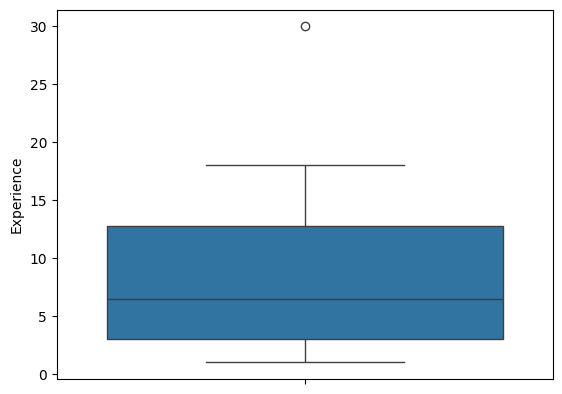

In [626]:
# sns.boxplot(y=X_train['Age'])
# sns.boxplot(y=X_train['Salary'])
sns.boxplot(y=X_train['Experience'])

# age and exp has outliers

In [627]:
# Step 2: Outlier capping


cols=['Age','Experience']

q1=X_train[cols].quantile(0.25)
q3=X_train[cols].quantile(0.75)

iqr=q3-q1

lb=(q1-1.5*iqr).clip(lower=0)
ub=q3+1.5*iqr

mask = ((X_train[cols] < lb) | (X_train[cols] > ub)).any(axis=1)

print(ub)
X_train[mask]

Age           53.750
Experience    27.375
dtype: float64


,Age,Salary,City,Education,Experience
5,60.0,75000.0,Dhaka,PhD,30


In [628]:
X_train[cols]=X_train[cols].clip(lb,ub,axis=1)
X_test[cols]=X_test[cols].clip(lb,ub,axis=1)

X_train[cols]

,Age,Experience
13,41.00,18.000
5,53.75,27.375
8,35.50,7.000
2,35.50,5.000
1,32.00,8.000
14,26.00,3.000
4,28.00,3.000
7,38.00,12.000
10,29.00,2.000
12,34.00,6.000


In [629]:
X_train

,Age,Salary,City,Education,Experience
13,41.00,63000.0,Dhaka,Masters,18.000
5,53.75,75000.0,Dhaka,PhD,27.375
8,35.50,41000.0,Dhaka,Masters,7.000
2,35.50,48000.0,Dhaka,Graduate,5.000
1,32.00,55000.0,Chittagong,Graduate,8.000
14,26.00,29000.0,Dhaka,HSC,3.000
4,28.00,32000.0,Dhaka,HSC,3.000
7,38.00,60000.0,Chittagong,Graduate,12.000
10,29.00,33000.0,Rajshahi,HSC,2.000
12,34.00,44500.0,Chittagong,Graduate,6.000


In [630]:
# Step 3: One-Hot Encoding
# Step 4: Ordinal Encoding
# Step 5: Standard Scaling


trf2=ColumnTransformer(transformers=[

                          ('ohe',OneHotEncoder(sparse_output=False,drop='first'),['City']),
                          ('oe',OrdinalEncoder(categories=[['HSC','Graduate','Masters','PhD']]),['Education']),
                          ('ss',StandardScaler(),['Age','Salary','Experience'])
                      ],

                       remainder='passthrough',
                       verbose_feature_names_out=False
                       ).set_output(transform='pandas')



X_train=trf2.fit_transform(X_train)
X_test=trf2.transform(X_test)


In [631]:
X_train

,City_Dhaka,City_Rajshahi,City_Sylhet,Education,Age,Salary,Experience
13,1.0,0.0,0.0,2.0,0.718748,1.191626,1.203732
5,1.0,0.0,0.0,3.0,2.240801,2.036917,2.450404
8,1.0,0.0,0.0,2.0,0.062175,-0.358075,-0.259031
2,1.0,0.0,0.0,1.0,0.062175,0.135012,-0.524988
1,0.0,0.0,0.0,1.0,-0.355643,0.628098,-0.126052
14,1.0,0.0,0.0,0.0,-1.071904,-1.203366,-0.790944
4,1.0,0.0,0.0,0.0,-0.833150,-0.992043,-0.790944
7,0.0,0.0,0.0,1.0,0.360617,0.980303,0.405861
10,0.0,1.0,0.0,0.0,-0.713774,-0.921602,-0.923923
12,0.0,0.0,0.0,1.0,-0.116890,-0.111531,-0.392009


In [635]:
print(X_train.shape,X_test.shape)

print('Pipeline complete!')

(12, 7) (3, 7)
Pipeline complete!
